In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical parameters.
m = 1 # mass
g = 10 # gravity
r = .2 # length
I = .1 # moment of inertia
T = 2 # time horizon

## HW

In [2]:
# Helper funcion the computes derivative of order n.
def derivative(f, t, h=1e-4):
    return (f(t + h) - f(t)) / h
def derivative_order_n(f, t, n):
    if n == 1:
        return derivative(f, t)
    else:
        df = lambda t: derivative(f, t)
        return derivative_order_n(df, t, n - 1)

# Differential flatness.
def fq3(t):
    ddq1 = derivative_order_n(fq1, t, 2)
    ddq2 = derivative_order_n(fq2, t, 2)
    return - np.arctan2(ddq1, ddq2 + g)
def u(t):
    ddq1 = derivative_order_n(fq1, t, 2)
    ddq2 = derivative_order_n(fq2, t, 2)
    ddq3 = derivative_order_n(fq3, t, 2)
    a = m * np.sqrt(ddq1 ** 2 + (ddq2 + g) ** 2) / 2
    b = I * ddq3 / 2 / r
    return np.array([a - b, a + b])

### Control the trajectory

#### Solver for $\dot{q}_3 = \ddot{q}_3 = 0$ at initial and final state

In [3]:
def solver_2p_w_q3_0(x_0, y_0, x_T, y_T, T):
    x0, dx0 = x_0
    xT, dxT = x_T
    y0, dy0 = y_0
    yT, dyT = y_T

    A = np.array([
        [T**4,    T**5,    T**6,    T**7],
        [4*T**3,  5*T**4,  6*T**5,  7*T**6],
        [12*T**2, 20*T**3, 30*T**4, 42*T**5],
        [24*T,    60*T**2, 120*T**3, 210*T**4]
    ], dtype=float)

    B = np.array([
        xT - x0 - dx0*T,
        dxT - dx0,
        0.0,
        0.0
    ], dtype=float)

    X = np.linalg.solve(A, B)

    a4, a5, a6, a7 = X
    a0 = x0
    a1 = dx0
    a2 = 0.0
    a3 = 0.0

    coeffs_a = np.array([a7, a6, a5, a4, a3, a2, a1, a0])
    #print(coeffs)

    C = np.array([
        [T**2,   T**3],
        [2*T,   3*T**2]
    ], dtype=float)

    D = np.array([
        yT - y0 - dy0*T,
        dyT - dy0
    ], dtype=float)

    Y = np.linalg.solve(C, D)

    b2, b3 = Y
    b0 = y0
    b1 = dy0

    coeffs_b = np.array([b3, b2, b1, b0])
    return coeffs_a, coeffs_b



In [4]:
# Center of mass trajectory
def fq2(t, A = [-0.25, 0.75, 0, 0]):
    
    q = np.array(A) @ np.array([t**3, t**2, t, 1]).T
    return q ### YOUR CODE HERE

def fq1(t, A = [-0.15625, 1.09375, -2.625, 2.1875, 0,  0, 0, 0]):
    q = np.array(A) @ np.array([t**7, t**6, t**5, t**4, t**3, t**2, t, 1]).T
    return q

### Plot quadrotor snapshots.

[-0.09375  0.65625 -1.575    1.3125   0.       0.       0.       0.5    ] [ 0.1375 -0.4125  0.      0.7   ]


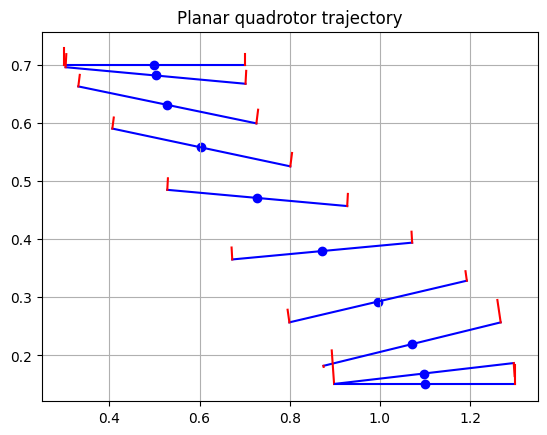

In [5]:
A, B = solver_2p_w_q3_0([0.5,0], [0.7,0], [1.1, 0], [.15, 0], 2)
print(A, B)
# Plot quadrotor snapshots.
plt.figure()
snapshots = 10
times = np.linspace(0, T, snapshots)
q_traj = []
u_traj = []
for t in times:
    q1t = fq1(t, A)
    q2t = fq2(t, B)
    q3t = fq3(t)
    q_traj.append([q1t,q2t, q3t])

    # Quadrotor body.
    c3t = np.cos(q3t)
    s3t = np.sin(q3t)
    endpoints = np.array([
        [q1t - r * c3t, q2t - r * s3t],
        [q1t + r * c3t, q2t + r * s3t]])
    plt.scatter(q1t, q2t, c='b')
    plt.plot(*endpoints.T, c='b')

    # Rotor thrusts as red segments.
    d = endpoints[1] - endpoints[0]
    v = np.array([-d[1], d[0]]) / 100
    thrust = u(t)
    u_traj.append(thrust)
    for ui, ei in zip(thrust, endpoints):
        force = np.array([ei, ei + v * ui])
        plt.plot(*force.T, c='r')

# Plot options.
plt.title('Planar quadrotor trajectory')
plt.grid()

## Project env test

In [6]:
snapshots = 10
times = np.linspace(0, T, snapshots)
q_traj = []
u_traj = []
checkpoints = [
    [0.25, 0, 0, 0,   0.5, 0, 0.7, 0],
    [0.5, 0, 0.7, 0,   1.1, 0, 0.15, 0],
    [1.1, 0, 0.15, 0,   1.75, 0, .5, 0]
]
for q1, dq1, q2, dq2, q1T, dq1T, q2T, dq2T in checkpoints:
    A, B = solver_2p_w_q3_0([q1, dq1], [q2, dq2], [q1T, dq1T], [q2T, dq2T], 2)
    for t in times:
        q1t = fq1(t, A)
        q2t = fq2(t, B)
        q3t = fq3(t)
        q_traj.append([q1t,q2t, q3t])
        thrust = u(t)
        u_traj.append(thrust)

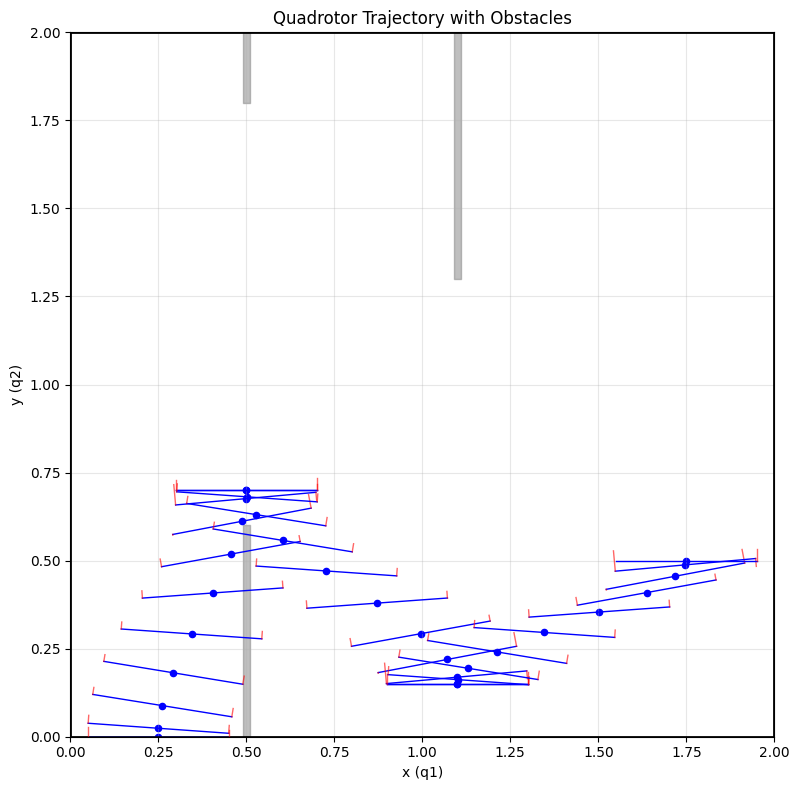

In [7]:
from plot_utils import *
plot_trajectory(2, 2, {'r': .2}, 
    [{'x': .5, 'uh': .2, 'bh': .6}, 
    {'x': 1.1, 'uh': 0.7, 'bh': 0}], 
    q_traj, 
    u_traj)